In [17]:
!pip install -q torch_snippets # instala biblioteca de utilitários
from torch_snippets import * # importa funções da biblioteca
from torchvision.datasets import MNIST # importa dataset de numeros
from torchvision import transforms # importa ferramentas de conversão
device = 'cuda' if torch.cuda.is_available() else 'cpu' # define uso de gpu ou cpu

In [18]:
img_transform = transforms.Compose([ # agrupa várias transformações
    transforms.ToTensor(), # converte imagem para tensor
    transforms.Normalize([0.5], [0.5]), # ajusta média e desvio padrão
    transforms.Lambda(lambda x: x.to(device)) # envia o dado
])

In [19]:
train_DS = MNIST('./content', train=True, download=True, transform=img_transform) # cria dataset de treino
val_DS = MNIST('./content', train=False, download=True, transform=img_transform) # cria dataset de validação

In [20]:
class AutoEncoder(nn.Module): # define a classe do modelo
    def __init__(self, latent_dim): # inicializa a estrutura
        super().__init__()
        self.latent_dim = latent_dim # guarda dimensão da camada
        self.encoder = nn.Sequential( # inicia bloco de compressão
            nn.Linear(28*28,128), nn.ReLU(True), # camada 1
            nn.Linear(128,64), nn.ReLU(True), # camada 2
            nn.Linear(64,latent_dim)) # saida
        self.decoder = nn.Sequential( # inicia bloco de reconstrucão
            nn.Linear(latent_dim,64),nn.ReLU(True), # camada 1
            nn.Linear(64,128),nn.ReLU(True), # camada 2
            nn.Linear(128,28*28),nn.Tanh()) # saida

    def forward(self,x): # define o fluxo de dados
        x = x.view(len(x), -1)
        x = self.encoder(x) # comprime os dados
        x = self.decoder(x) # reconstrói os dados
        x = x.view(len(x), 1, 28, 28) # volta para formato de imagem
        return x # retorna imagem

In [21]:
def train_batch(input, model, optimizer, criterion): # função de trein
    model.train()
    input = input.to(device) # move entrada
    optimizer.zero_grad() # zera gradientes
    output = model(input) # gera a reconstrução
    loss = criterion(output, input) # calcula erro
    loss.backward() # calcula gradientes
    optimizer.step() # atualiza os pesos
    return loss # retorna

@torch.no_grad() # desativa cálculo de gradientes
def validate_batch(input, model, criterion): # função de validação do lote
    model.eval() # liga modo de avaliação
    input = input.to(device) # move entrada
    output = model(input) # gera a reconstrução
    loss = criterion(output, input) # calcula erro de validação
    return loss # retorna o erro

<div><div><progress max="5" value="0"></progress> 0.00% [0/5 00:00&lt;?]</div><div></div><div><progress max="60000" value="29209"></progress> 48.68% [29209/60000 03:50&lt;04:03... Train Loss: 0.2532]</div></div>

<div><p>Epoch 1: Train Loss=0.1580, Val Loss=0.1591</p><p>Epoch 2: Train Loss=0.1451, Val Loss=0.1536</p><p>Epoch 3: Train Loss=0.1427, Val Loss=0.1534</p><p>Epoch 4: Train Loss=0.1415, Val Loss=0.1502</p><p>Epoch 5: Train Loss=0.1408, Val Loss=0.1524</p></div>

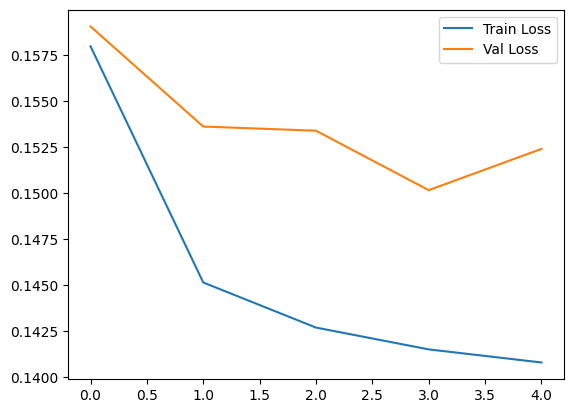

In [23]:
from fastprogress.fastprogress import master_bar, progress_bar # importa barras

model = AutoEncoder(3).to(device) # cria modelo com
criterion = nn.MSELoss() # define erro quadrático médio
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-5) # define otimizador
num_epochs = 5 # define total de épocas
train_losses, val_losses = [], []

mb = master_bar(range(num_epochs)) # barra principal de épocas
for epoch in mb: # loop de épocas
    trn_loss_epoch = 0 # zera erro de treino da época
    for ix, (data, _) in enumerate(progress_bar(train_DS, parent=mb)): # loop de treino
        loss = train_batch(data, model, optimizer, criterion) # treina lote
        trn_loss_epoch += loss.item() # acumula erro
        mb.child.comment = f"Train Loss: {loss.item():.4f}" # exibe erro atual
    train_losses.append(trn_loss_epoch / len(train_DS)) # salva média de treino

    val_loss_epoch = 0 # zera erro de validação da época
    for ix, (data, _) in enumerate(progress_bar(val_DS, parent=mb)): # loop de validação
        loss = validate_batch(data, model, criterion) # testa lote
        val_loss_epoch += loss.item() # acumula erro
        mb.child.comment = f"Val Loss: {loss.item():.4f}" # exibe erro atual
    val_losses.append(val_loss_epoch / len(val_DS)) # salva média de validação

    mb.write(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}") # log da época

import matplotlib.pyplot as plt # importa biblioteca de gráficos
plt.plot(train_losses, label='Train Loss') # plota curva de treino
plt.plot(val_losses, label='Val Loss') # plota curva de validação
plt.legend() # mostra legenda
plt.show() # exibe o gráfico

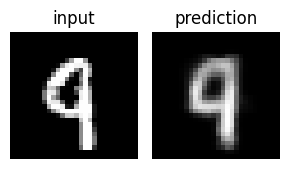

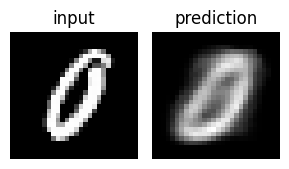

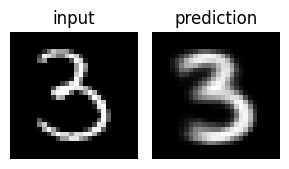

In [24]:
model.eval()

for _ in range(3):
    ix = np.random.randint(len(val_DS))
    im, _ = val_DS[ix]

    im = im.to(device)

    with torch.no_grad():
        _im = model(im[None])[0].cpu()

    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0].cpu(), ax=ax[0], title='input') # mostra a imagem original
    show(_im[0], ax=ax[1], title='prediction') # mostra a reconstrução
    plt.tight_layout()
    plt.show()